# SMS Spam Detection with Naive Bayes

## Goals
- preprocess SMS text
- build TF-IDF features
- train a `MultinomialNB` classifier
- evaluate results and inspect misclassifications

## Assignment Instructions

Build a text classification model to label SMS messages as **spam** or **ham**.

### Required tasks
1. Load the dataset and preprocess the text
2. Apply TF-IDF vectorization
3. Split the data into train/test sets
4. Train a `MultinomialNB` classifier
5. Evaluate with accuracy, precision, recall, and F1-score
6. Visualize the confusion matrix
7. Analyze false positives and false negatives

In [2]:
# Import libraries
import re   # Regular expressions for text preprocessing. install with: pip install regex
import urllib.request # For downloading datasets from the web. No installation needed as it's part of the Python standard library.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Optional NLP preprocessing helpers
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
except OSError:
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to /home/fredc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Load the SMS Spam Collection dataset
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
urllib.request.urlretrieve(url, 'sms.tsv')

sms_data = pd.read_csv('sms.tsv', sep='\t', header=None, names=['label', 'message'])

print('Shape:', sms_data.shape)
display(sms_data.head())
print('\nLabel distribution:')
print(sms_data['label'].value_counts())
print('\nMissing values:')
print(sms_data.isna().sum())
print('\nDuplicate rows:', sms_data.duplicated().sum())

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403


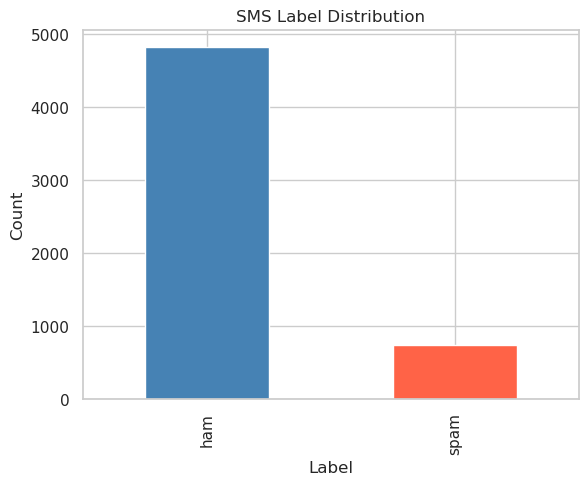

In [4]:
# Visualize class balance
ax = sms_data['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
ax.set_title('SMS Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.show()

## Text Preprocessing

This step lowercases each message, tokenizes words, removes stopwords, and applies stemming.

In [5]:
# Preprocess the message text
# We compare two normalization methods:
# 1) stemming: reduces words to shortened roots (for example, "crazy" -> "crazi")
# 2) spaCy lemmatization: reduces words to dictionary base forms (for example, "running" -> "run")

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text_stem(text):
    text = text.lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words]
    return ' '.join(tokens)

def preprocess_text_spacy(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if token.is_alpha and token.text not in stop_words
    ]
    return ' '.join(tokens)

sms_data['cleaned_text_stem'] = sms_data['message'].apply(preprocess_text_stem)
sms_data['cleaned_text_spacy'] = sms_data['message'].apply(preprocess_text_spacy)

# Keep the original column name for compatibility with later cells
sms_data['cleaned_text'] = sms_data['cleaned_text_stem']

display(sms_data[['label', 'message', 'cleaned_text_stem', 'cleaned_text_spacy']].head())

,label,message,cleaned_text_stem,cleaned_text_spacy
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,free entry wkly comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,nah think go usf live around though


## Feature Extraction and Model Training

We use TF-IDF features and a `MultinomialNB` classifier as the baseline model.

In [6]:
# Prepare the text data for comparing stemming and spaCy lemmatization
y = sms_data['label']

preprocessing_options = {
    'stemming': sms_data['cleaned_text_stem'],
    'spaCy lemmatization': sms_data['cleaned_text_spacy']
}

print('Prepared preprocessing options for comparison:')
for method_name in preprocessing_options:
    print(f'- {method_name}')

Prepared preprocessing options for comparison:
- stemming
- spaCy lemmatization


In [7]:
# Compare stemming vs spaCy lemmatization and tune alpha for Multinomial Naive Bayes
alpha_values = [0.1, 0.5, 1.0, 2.0]
comparison_results = []

for method_name, text_series in preprocessing_options.items():
    X = text_series
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    vectorizer_tmp = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    X_train_tfidf_tmp = vectorizer_tmp.fit_transform(X_train_tmp)
    X_test_tfidf_tmp = vectorizer_tmp.transform(X_test_tmp)

    for alpha in alpha_values:
        candidate_model = MultinomialNB(alpha=alpha)
        candidate_model.fit(X_train_tfidf_tmp, y_train_tmp)
        candidate_pred = candidate_model.predict(X_test_tfidf_tmp)
        report = classification_report(y_test_tmp, candidate_pred, output_dict=True)

        comparison_results.append({
            'method': method_name,
            'alpha': alpha,
            'accuracy': accuracy_score(y_test_tmp, candidate_pred),
            'spam_precision': report['spam']['precision'],
            'spam_recall': report['spam']['recall'],
            'spam_f1': report['spam']['f1-score']
        })

comparison_results_df = pd.DataFrame(comparison_results).sort_values(
    by=['spam_f1', 'accuracy'], ascending=False
).reset_index(drop=True)

print('Preprocessing + alpha tuning results:')
display(comparison_results_df)

best_method = comparison_results_df.loc[0, 'method']
best_alpha = float(comparison_results_df.loc[0, 'alpha'])

X = preprocessing_options[best_method]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB(alpha=best_alpha)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

print(f'\nBest preprocessing method: {best_method}')
print(f'Best alpha: {best_alpha}')
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

Preprocessing + alpha tuning results:


,method,alpha,accuracy,spam_precision,spam_recall,spam_f1
0,stemming,0.1,0.981166,0.992308,0.865772,0.924731
1,spaCy lemmatization,0.1,0.977578,0.976923,0.852349,0.910394
2,spaCy lemmatization,0.5,0.977578,1.000000,0.832215,0.908425
3,stemming,0.5,0.974888,0.991870,0.818792,0.897059
4,stemming,1.0,0.970404,1.000000,0.778523,0.875472
5,spaCy lemmatization,1.0,0.967713,1.000000,0.758389,0.862595
6,stemming,2.0,0.956951,1.000000,0.677852,0.808000
7,spaCy lemmatization,2.0,0.948879,1.000000,0.617450,0.763485



Best preprocessing method: stemming
Best alpha: 0.1
Accuracy: 0.9812

Classification report:

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Interpretation of the Classification Report

The model performs well overall, with **97.04% accuracy**. It is especially strong at identifying **ham** messages.

For **spam**, the **78% recall** means the model correctly catches about **78 out of every 100 actual spam messages**, while about **22 out of 100** are missed and predicted as ham.

In short, the model is reliable, but it could still be improved by detecting more spam messages.

**Addendum Notes:**
1. Accuracy improved to **98.12%** after training with best alpha.
2. For **spam**, the **87% recall**.

In [14]:
# Compare different n-gram ranges using the current stemming process
ngram_options = {
    'unigrams only (1,1)': (1, 1),
    'unigrams + bigrams (1,2)': (1, 2),
    'unigrams + bigrams + trigrams (1,3)': (1, 3)
}

ngram_results = []
alpha_to_use = best_alpha if 'best_alpha' in globals() else 0.1

X = sms_data['cleaned_text_stem']
y = sms_data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for label, ngram_range in ngram_options.items():
    vectorizer_candidate = TfidfVectorizer(ngram_range=ngram_range, min_df=2)
    X_train_tfidf_candidate = vectorizer_candidate.fit_transform(X_train)
    X_test_tfidf_candidate = vectorizer_candidate.transform(X_test)

    model_candidate = MultinomialNB(alpha=alpha_to_use)
    model_candidate.fit(X_train_tfidf_candidate, y_train)
    y_pred_candidate = model_candidate.predict(X_test_tfidf_candidate)
    report = classification_report(y_test, y_pred_candidate, output_dict=True)

    ngram_results.append({
        'ngram_setting': label,
        'accuracy': accuracy_score(y_test, y_pred_candidate),
        'spam_precision': report['spam']['precision'],
        'spam_recall': report['spam']['recall'],
        'spam_f1': report['spam']['f1-score']
    })

ngram_results_df = pd.DataFrame(ngram_results).sort_values(
    by=['spam_f1', 'accuracy'], ascending=False
).reset_index(drop=True)

print('N-gram comparison results (using stemming):')
display(ngram_results_df)

best_ngram_label = ngram_results_df.loc[0, 'ngram_setting'] 
# Get the label of the best n-gram setting based on spam F1-score (and accuracy as tiebreaker)
best_ngram_range = ngram_options[best_ngram_label] 
# Get the n-gram range tuple corresponding to the best label

print(f'\nBest n-gram setting: {best_ngram_label}')
print(f'Alpha used: {alpha_to_use}')

N-gram comparison results (using stemming):


,ngram_setting,accuracy,spam_precision,spam_recall,spam_f1
0,"unigrams + bigrams (1,2)",0.981166,0.992308,0.865772,0.924731
1,"unigrams only (1,1)",0.980269,0.984733,0.865772,0.921429
2,"unigrams + bigrams + trigrams (1,3)",0.979372,0.992188,0.852349,0.916968



Best n-gram setting: unigrams + bigrams (1,2)
Alpha used: 0.1


In [9]:
# Verify how stemming affects n-gram features
feature_names = vectorizer.get_feature_names_out()

print("Sample n-gram features with stemming applied:")
sample_features = [f for f in feature_names if ' ' in f][:20]   # shows multi-word features
print(sample_features)

Sample n-gram features with stemming applied:
['aathi dear', 'aathi love', 'abl come', 'abl deliv', 'abt alreadi', 'abt tht', 'abta complimentari', 'aburo enjoy', 'ac nat', 'accept brother', 'accept day', 'accid claim', 'accident delet', 'account bank', 'account detail', 'account lt', 'account statement', 'aco entri', 'across sea', 'action www']


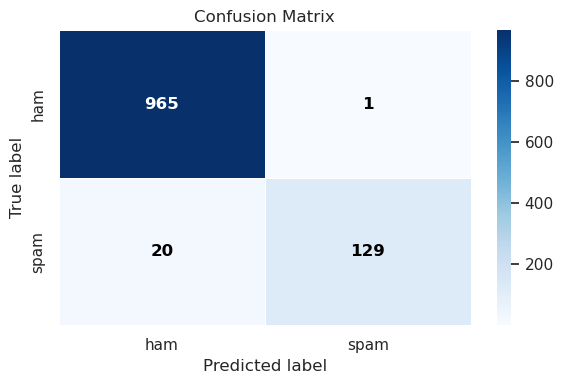

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
    linewidths=0.5,
    linecolor='white'
)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5, i + 0.5, f'{cm[i, j]}',
            ha='center', va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=12, fontweight='bold'
        )

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## Interpretation of the Confusion Matrix

The confusion matrix shows that the model classifies most messages correctly. It correctly predicted **966 ham** messages and **116 spam** messages.

It made **0 false positives**, so no ham messages were wrongly marked as spam. However, it missed **33 spam** messages by predicting them as ham.

Overall, the model performs well, but improving spam detection would make it even better.


**Addendum Notes:**
1. After fine-tuning the alpha for training, it correctly predicted **965 ham** messages and **129 spam** messages. 1 false positive, and missed 20 spam messages.

In [11]:
# Verify how stemming affects n-gram features
feature_names = vectorizer.get_feature_names_out()

print("Sample n-gram features with stemming applied:")
sample_features = [f for f in feature_names if ' ' in f][:20]   # shows multi-word features
print(sample_features)

Sample n-gram features with stemming applied:
['aathi dear', 'aathi love', 'abl come', 'abl deliv', 'abt alreadi', 'abt tht', 'abta complimentari', 'aburo enjoy', 'ac nat', 'accept brother', 'accept day', 'accid claim', 'accident delet', 'account bank', 'account detail', 'account lt', 'account statement', 'aco entri', 'across sea', 'action www']


In [12]:
# Explore important features for spam and ham
feature_names = np.array(vectorizer.get_feature_names_out())
log_probs = model.feature_log_prob_

ham_top = feature_names[np.argsort(log_probs[0])[-15:]][::-1]
spam_top = feature_names[np.argsort(log_probs[1])[-15:]][::-1]

print('Top ham features:')
print(ham_top)
print('\nTop spam features:')
print(spam_top)

Top ham features:
['ok' 'go' 'get' 'come' 'call' 'gt' 'lt' 'got' 'know' 'good' 'time'
 'lt gt' 'like' 'sorri' 'want']

Top spam features:
['call' 'free' 'txt' 'text' 'claim' 'mobil' 'stop' 'repli' 'ur' 'prize'
 'servic' 'www' 'cash' 'min' 'uk']


In [13]:
# Analyze false positives and false negatives
results = pd.DataFrame({
    'message': X_test,
    'true_label': y_test,
    'predicted_label': y_pred
}).reset_index(drop=True)

false_positives = results[(results['true_label'] == 'ham') & (results['predicted_label'] == 'spam')]
# False positives are messages that were actually "ham" (not spam) but were incorrectly classified as "spam" by the model.
false_negatives = results[(results['true_label'] == 'spam') & (results['predicted_label'] == 'ham')]
# False negatives are messages that were actually "spam" but were incorrectly classified as "ham" by the model.

print('False positives:', len(false_positives))
display(false_positives.head(5))

print('False negatives:', len(false_negatives))
display(false_negatives.head(5))

False positives: 1


,message,true_label,predicted_label
78,u receiv msg,ham,spam


False negatives: 20


,message,true_label,predicted_label
44,freemsg hey darl week' word back like fun stil...,spam,ham
123,talk sexi make new friend fall love world disc...,spam,ham
196,ringtonek,spam,ham
219,sorri miss call let' talk time,spam,ham
235,latest news polic station toilet stolen cop no...,spam,ham


## Short Analysis

Possible improvements:
1. tune the Naive Bayes smoothing parameter `alpha` by testing several values such as `0.1`, `0.5`, `1.0`, and `2.0` **(Done. 0.1 is the best alpha)**
2. compare stemming with lemmatization **(Done. Added comparison with spaCy lemmatization process)**
3. use **n-grams** alongside the current stemming process by expanding the TF-IDF vectorizer to capture phrases such as bigrams and trigrams, which may improve the model by preserving more context from the SMS messages **(Done. Using Bigrams)**